# **Graph Analysis**

**Dataset: StarPep (sequences from 10 to 100 amino acids)**

In [1]:
import pandas as pd
import sys
import os
from plot import (
    plot_inter_amino_acid_distances,
    create_merge_similarity_matrix, 
    plot_merge_similarity_matrix, 
    plot_density, 
    statistics2
)

base_path = 'data/Paper/StarPep-Analysis-2024-12-04T01.07.53/Graph_Analysis/'
output_base_path = 'output/Paper/'

## **Inter-amino acid distances**

### **Statistics**

In [2]:
distance_functions = [
    'euclidean', 'angular_separation', 'bhattacharyya', 'canberra', 
    'clark', 'lance_williams', 'soergel'
]
output_filepath = f'{output_base_path}Statistics.csv'
percentiles = [0.25, 0.50, 0.75]

stats_by_function = statistics2(base_path, distance_functions, output_filepath, percentiles)
stats_by_function.head(7)

Processing distance functions: 100%|██████████| 7/7 [01:33<00:00, 13.41s/it]


,distance_function,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
0,angular_separation,25688946.0,0.131011,0.164412,2.814799e-09,0.018027,0.065390,0.179948,1.000000,1.999451,4.267553
1,bhattacharyya,25688946.0,2.737850,1.620385,9.118815e-02,1.515764,2.430412,3.645232,20.357421,1.043045,1.339510
2,canberra,25688946.0,1.085541,0.597095,1.253596e-02,0.615481,1.014184,1.471174,3.000000,0.588522,-0.141860
3,clark,25688946.0,0.707474,0.361186,1.008155e-02,0.416101,0.681320,0.983046,1.732051,0.312449,-0.633705
4,euclidean,25688946.0,20.126474,13.689747,7.187549e-01,10.283634,16.613239,26.241980,254.056279,1.542797,3.937100
5,lance_williams,25688946.0,0.339796,0.203929,5.685703e-03,0.178902,0.304133,0.465998,1.000000,0.750031,0.041840
6,soergel,25688946.0,0.474613,0.217372,1.130712e-02,0.303506,0.466414,0.635742,1.000000,0.171448,-0.770495


### **Distributions**

#### **Angular separation**

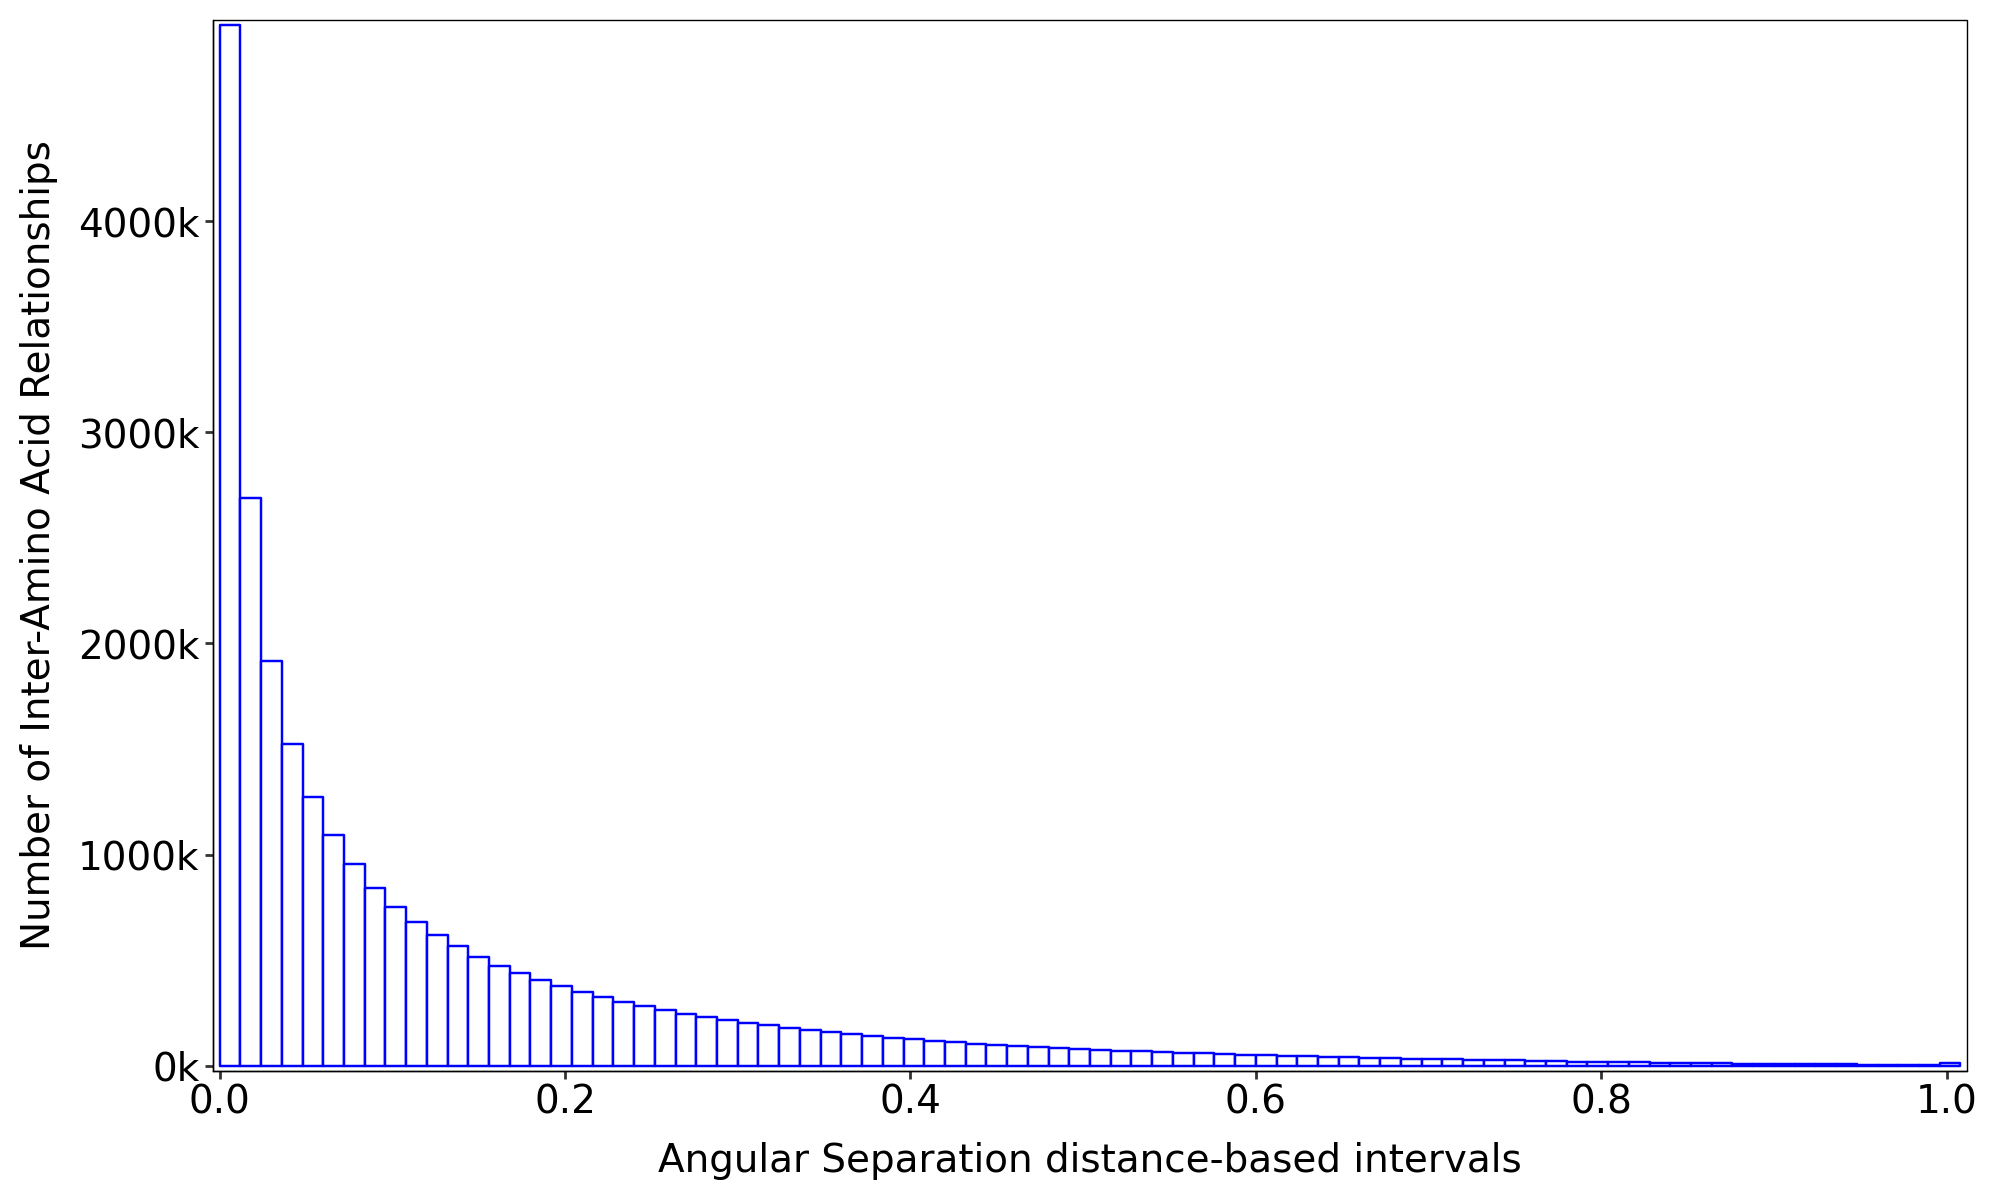

In [2]:
distance_function = 'angular_separation'
x_axis_step = 0.2 
binwidth = 0.012

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Bhattacharyya**

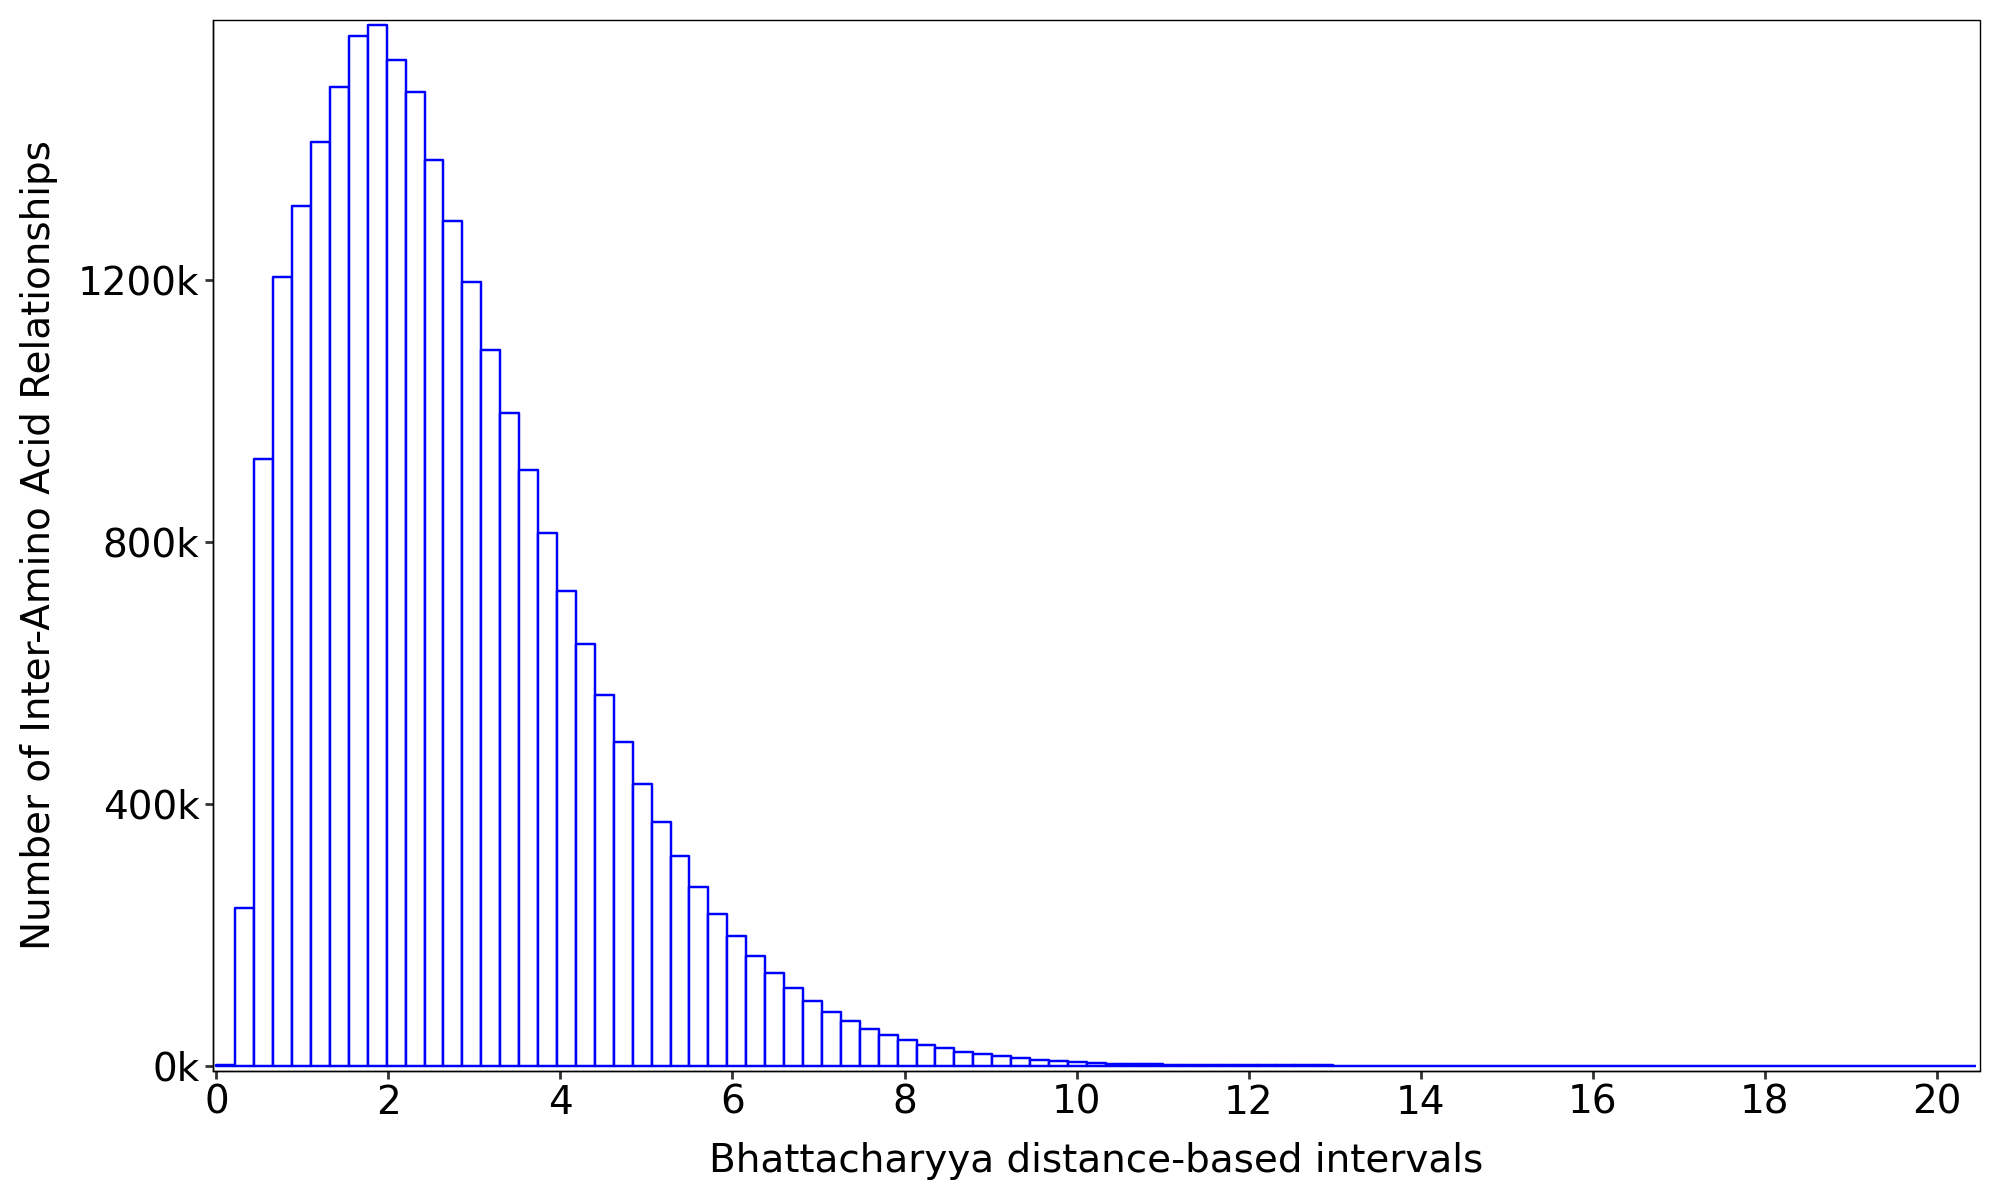

In [3]:
distance_function = 'bhattacharyya'
x_axis_step = 2
binwidth = 0.22

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Canberra**

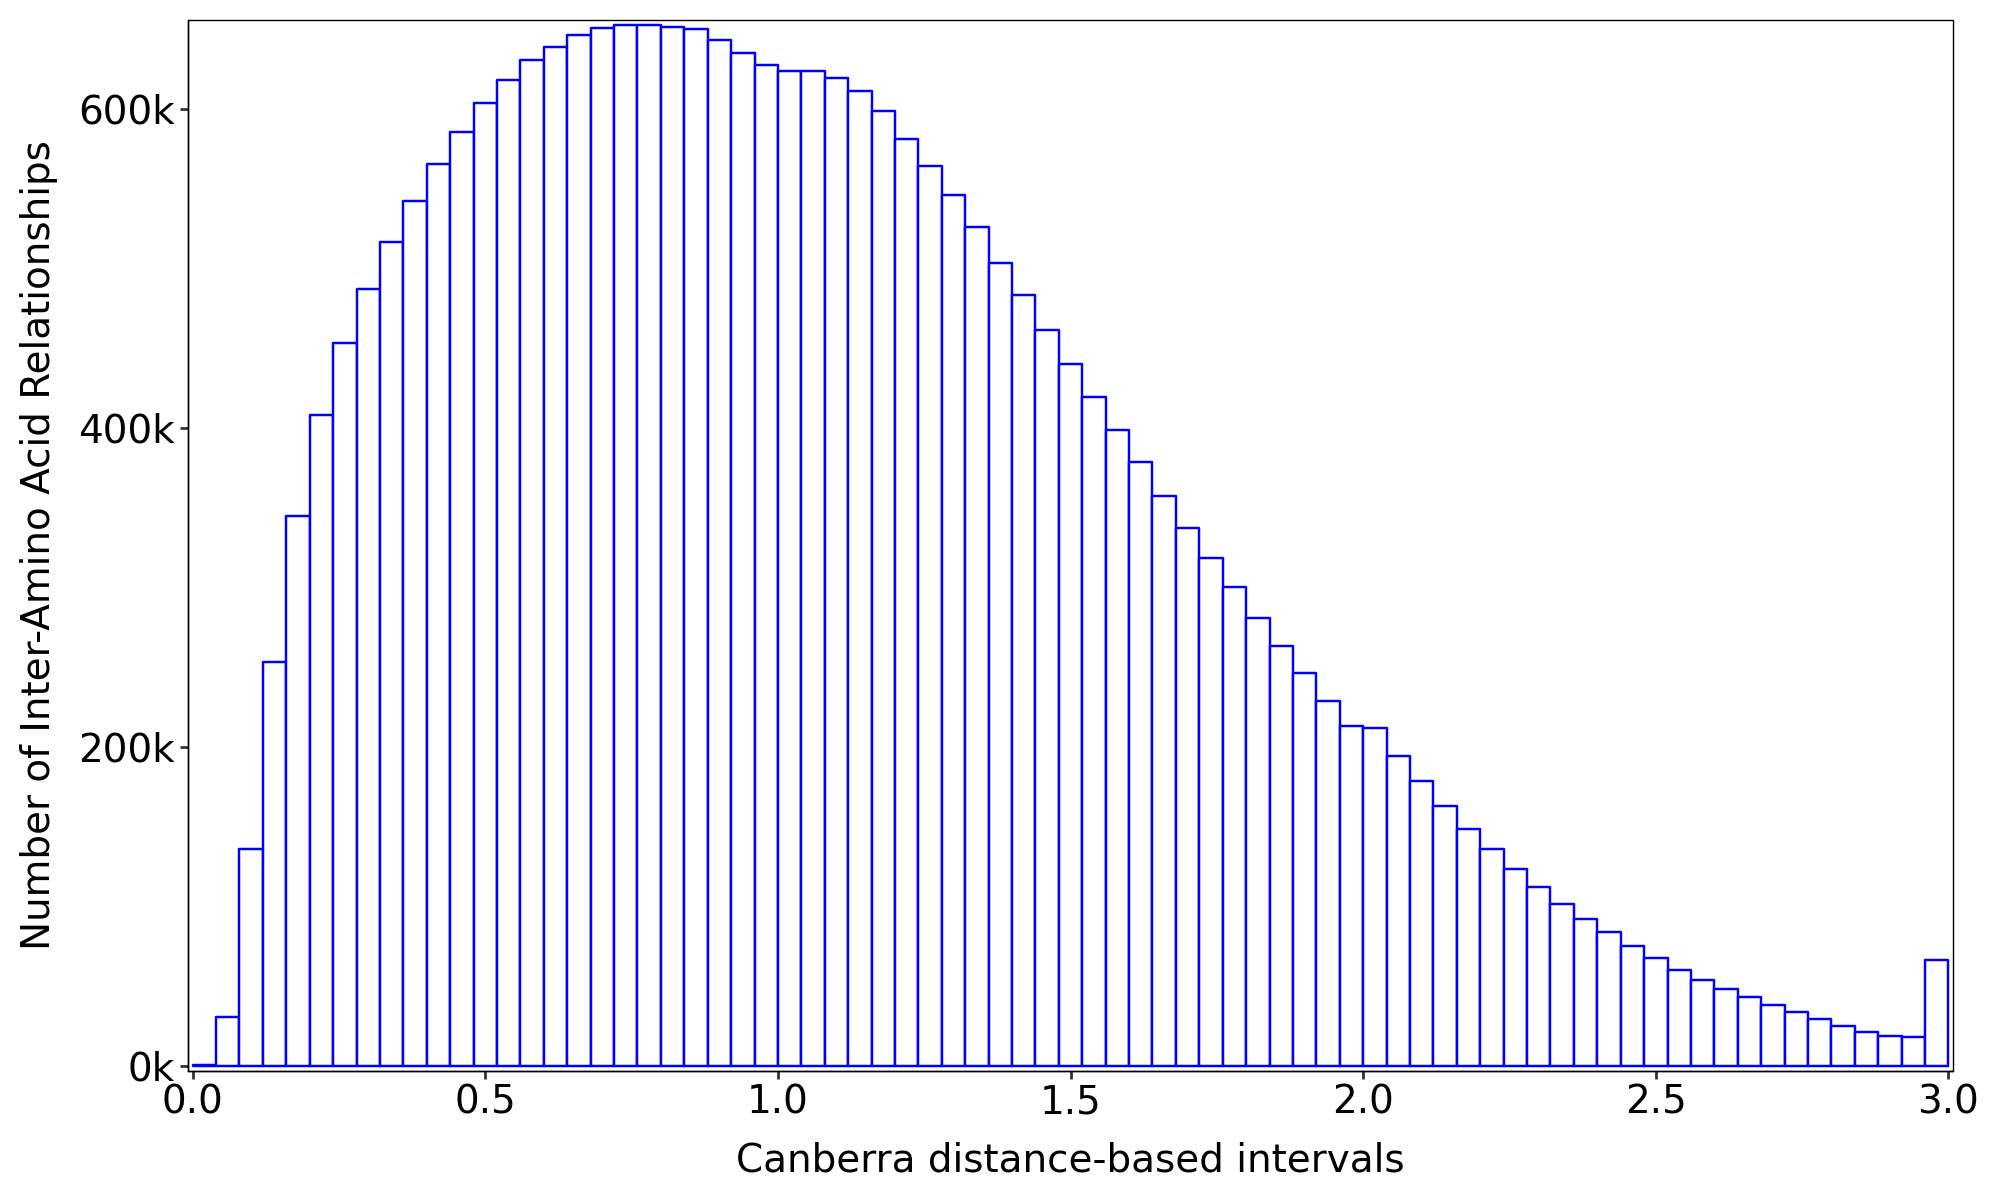

In [4]:
distance_function = 'canberra'
x_axis_step = 0.5
binwidth = 0.04

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Clark**

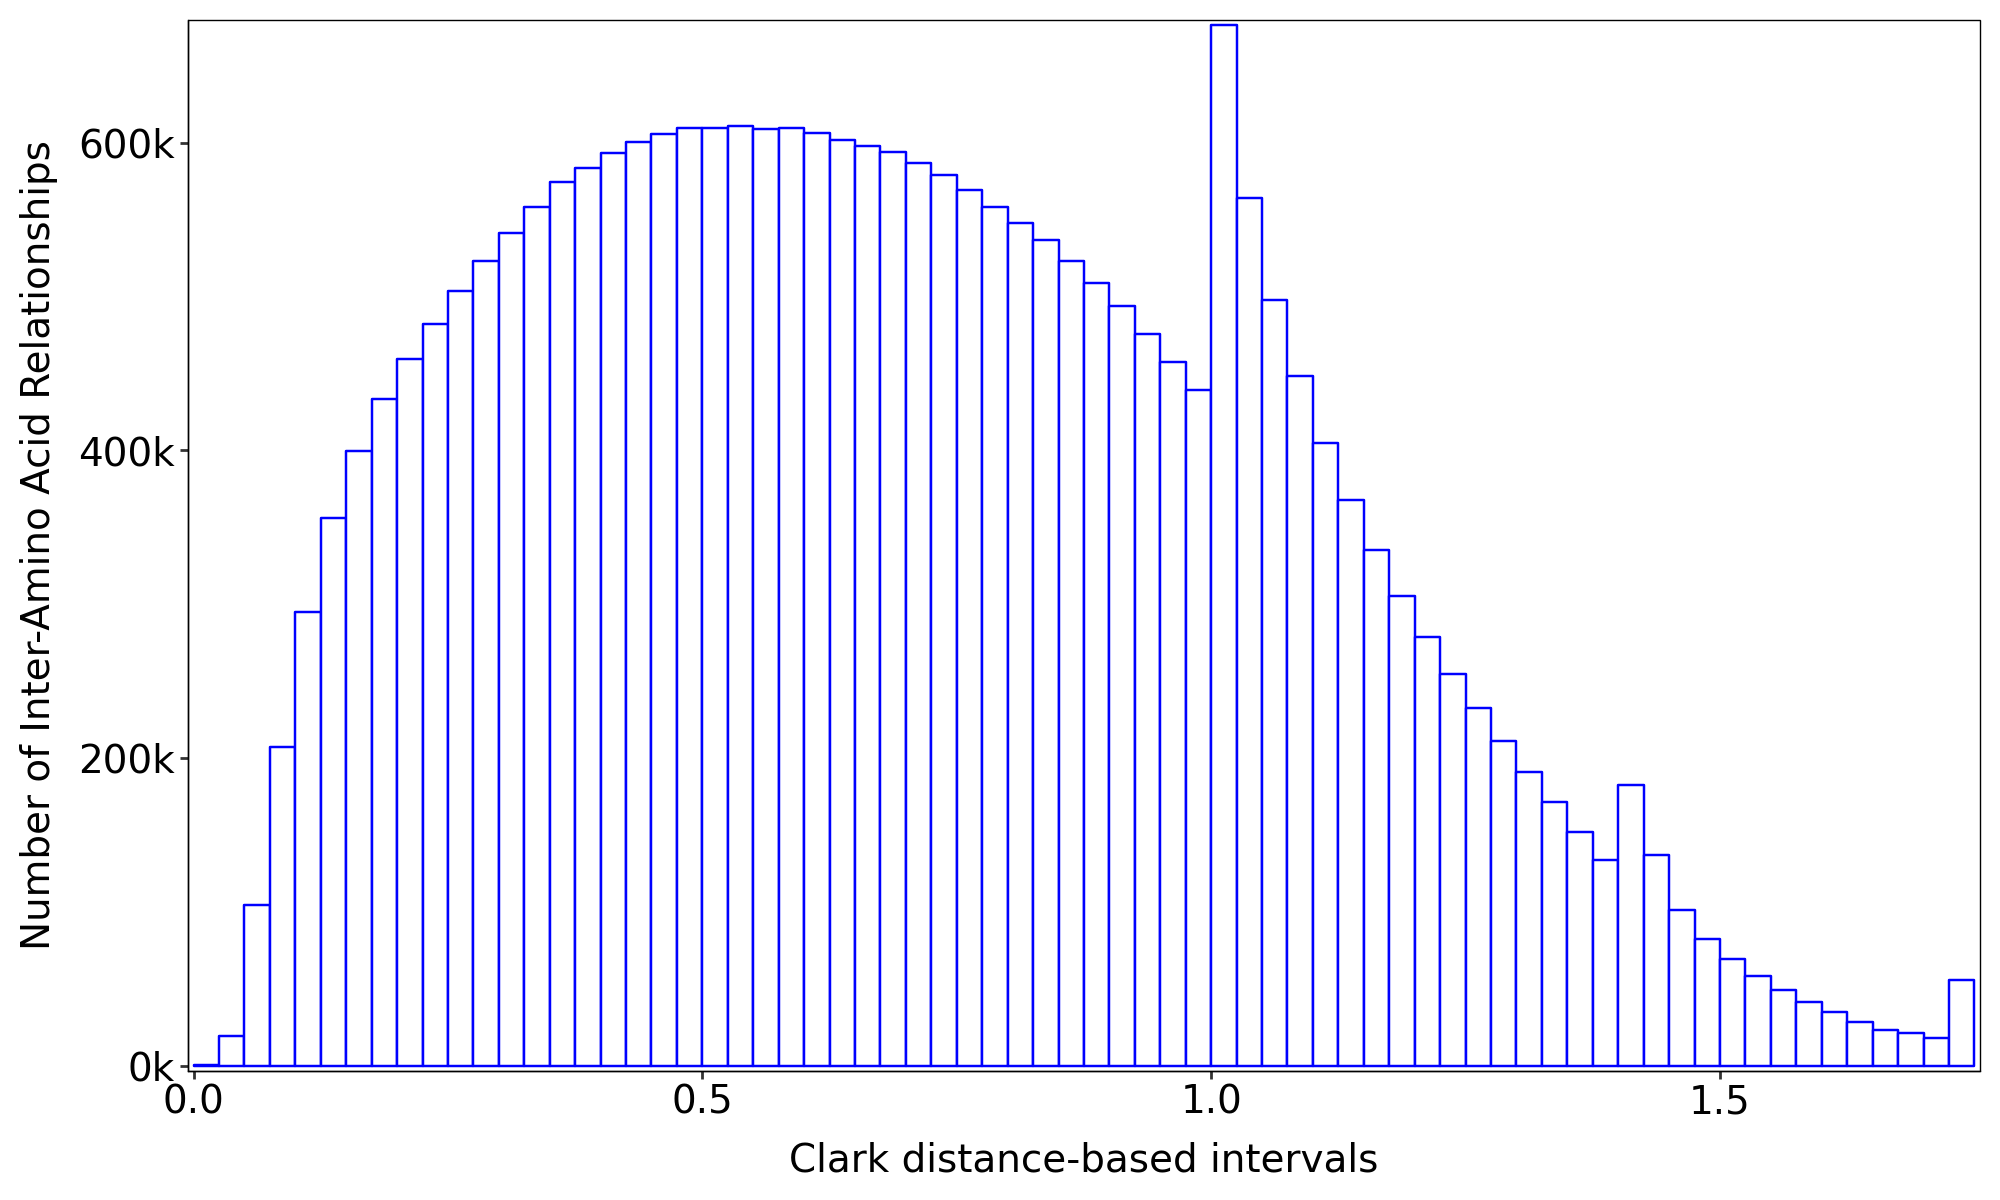

In [5]:
distance_function = 'clark'
x_axis_step = 0.5
binwidth = 0.025

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Euclidean**

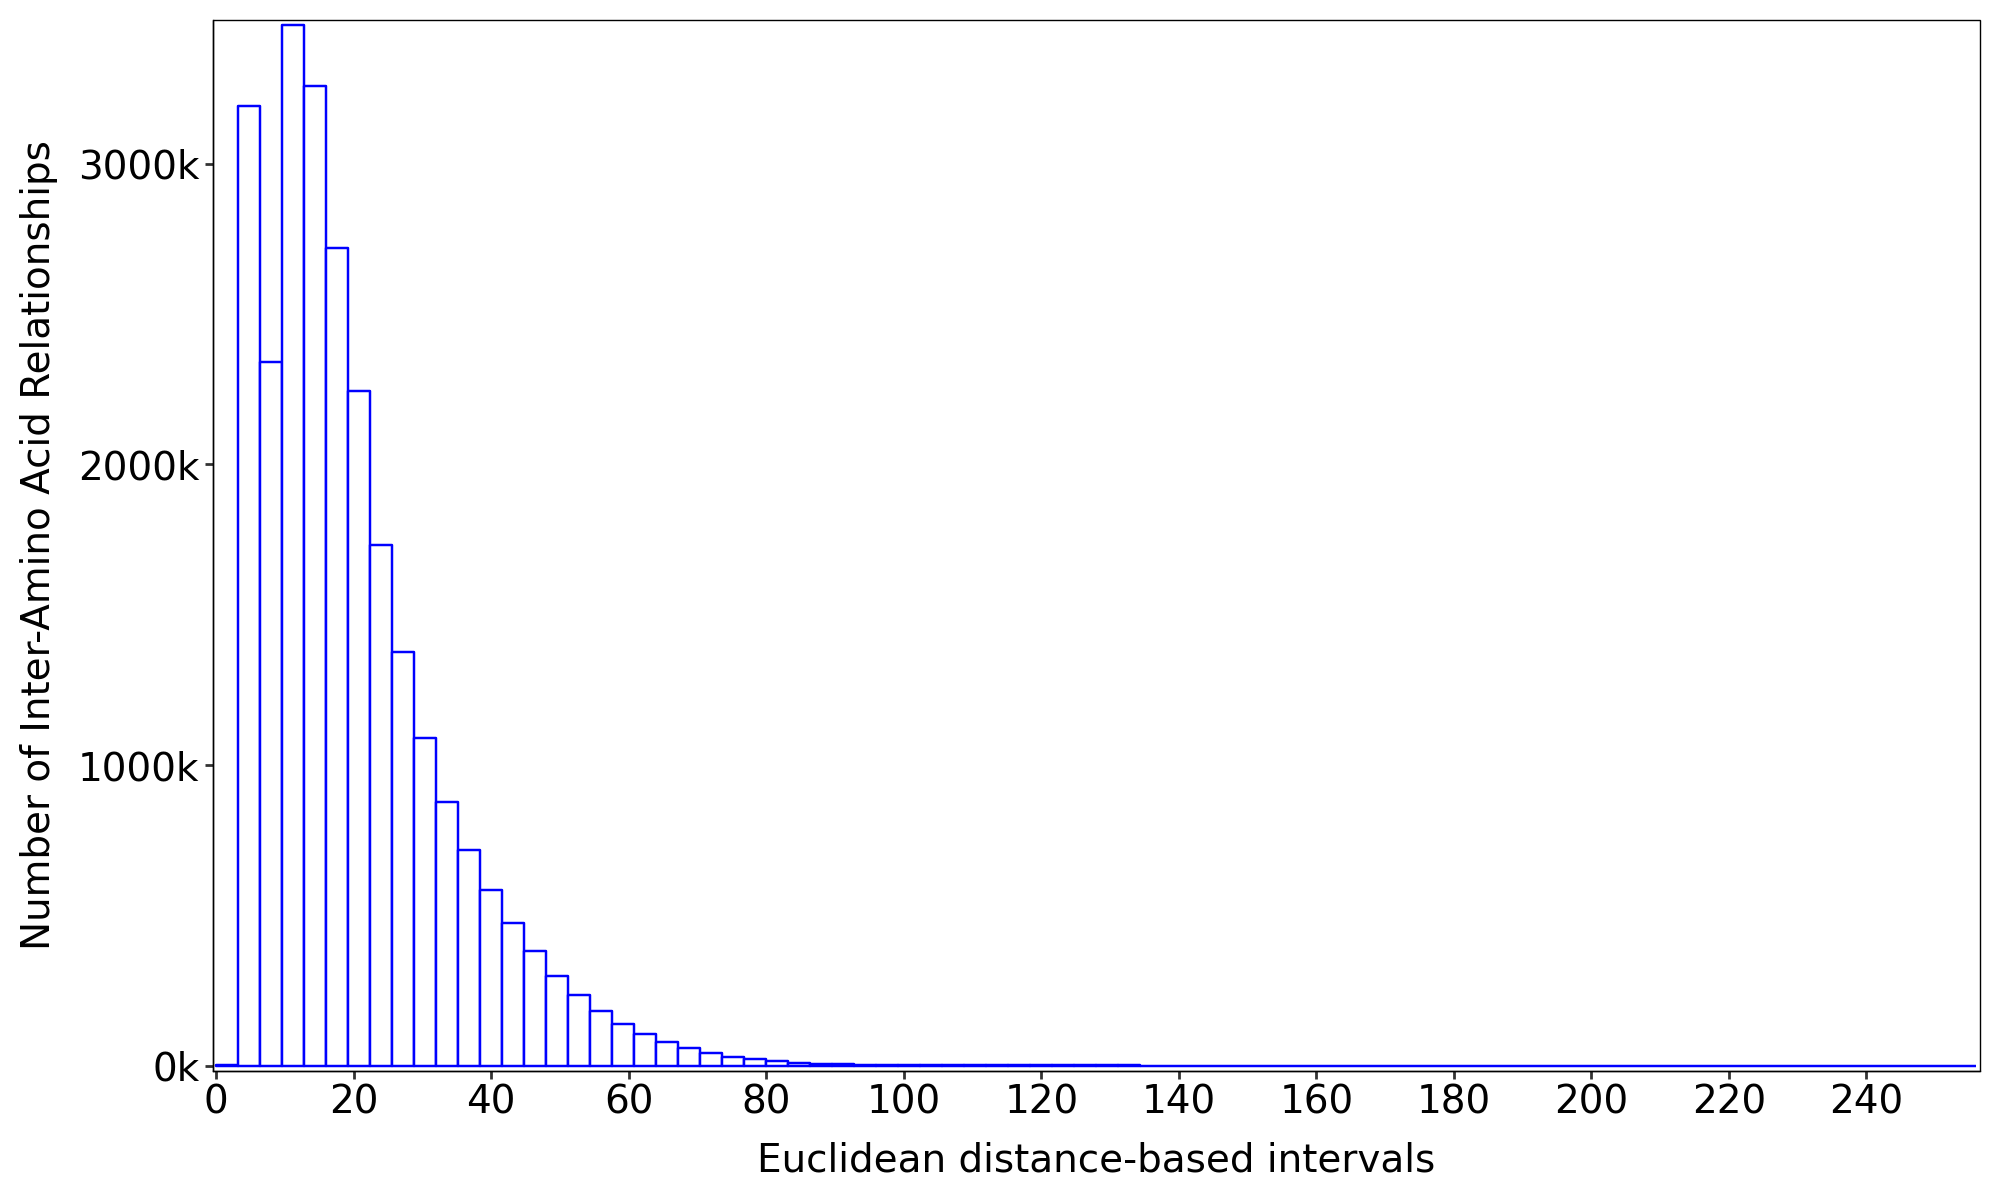

In [6]:
distance_function = 'euclidean'
x_axis_step = 20
binwidth = 3.2

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Lance Williams**

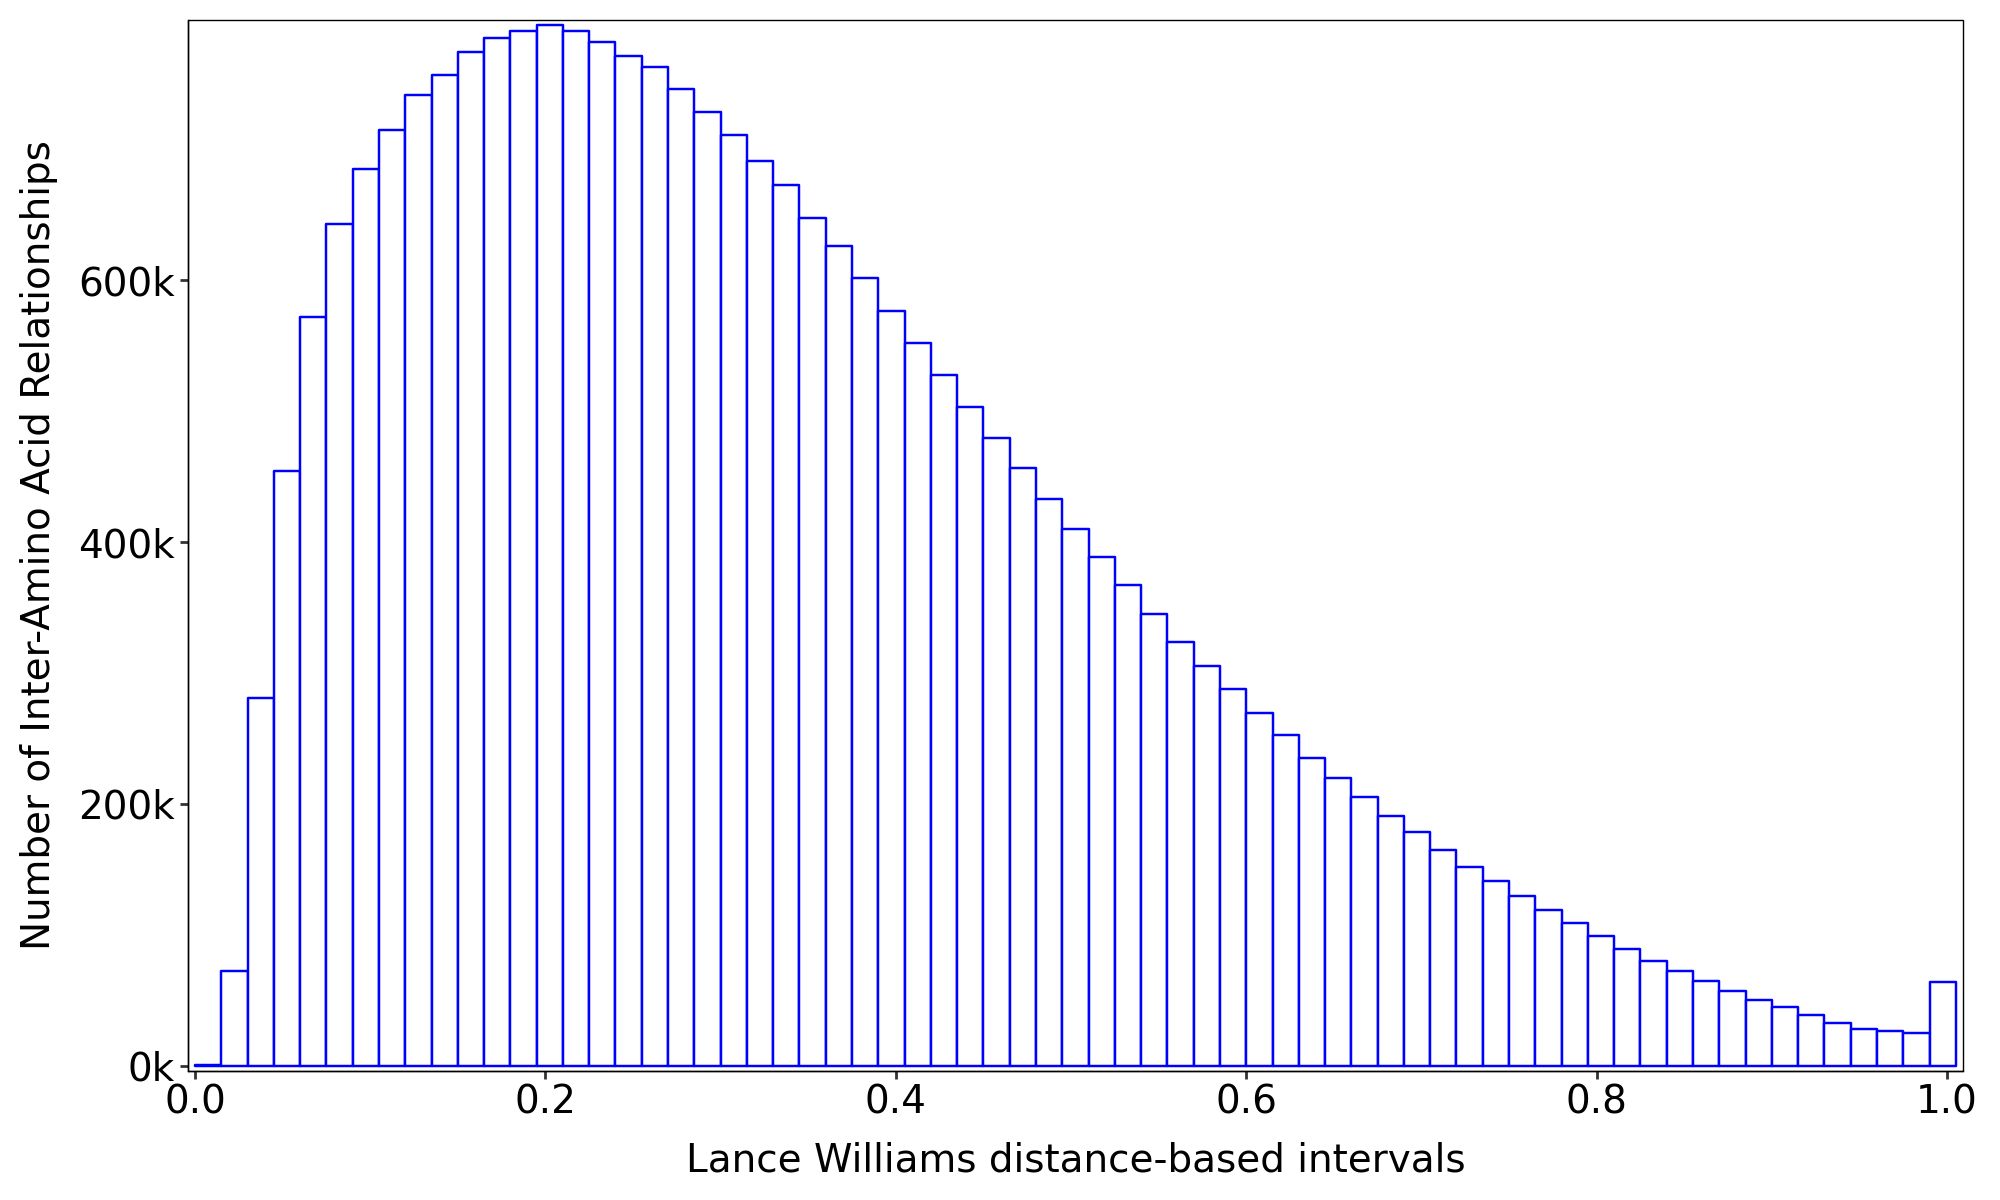

In [7]:
distance_function = 'lance_williams'
x_axis_step = 0.2
binwidth = 0.015

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

#### **Soergel**

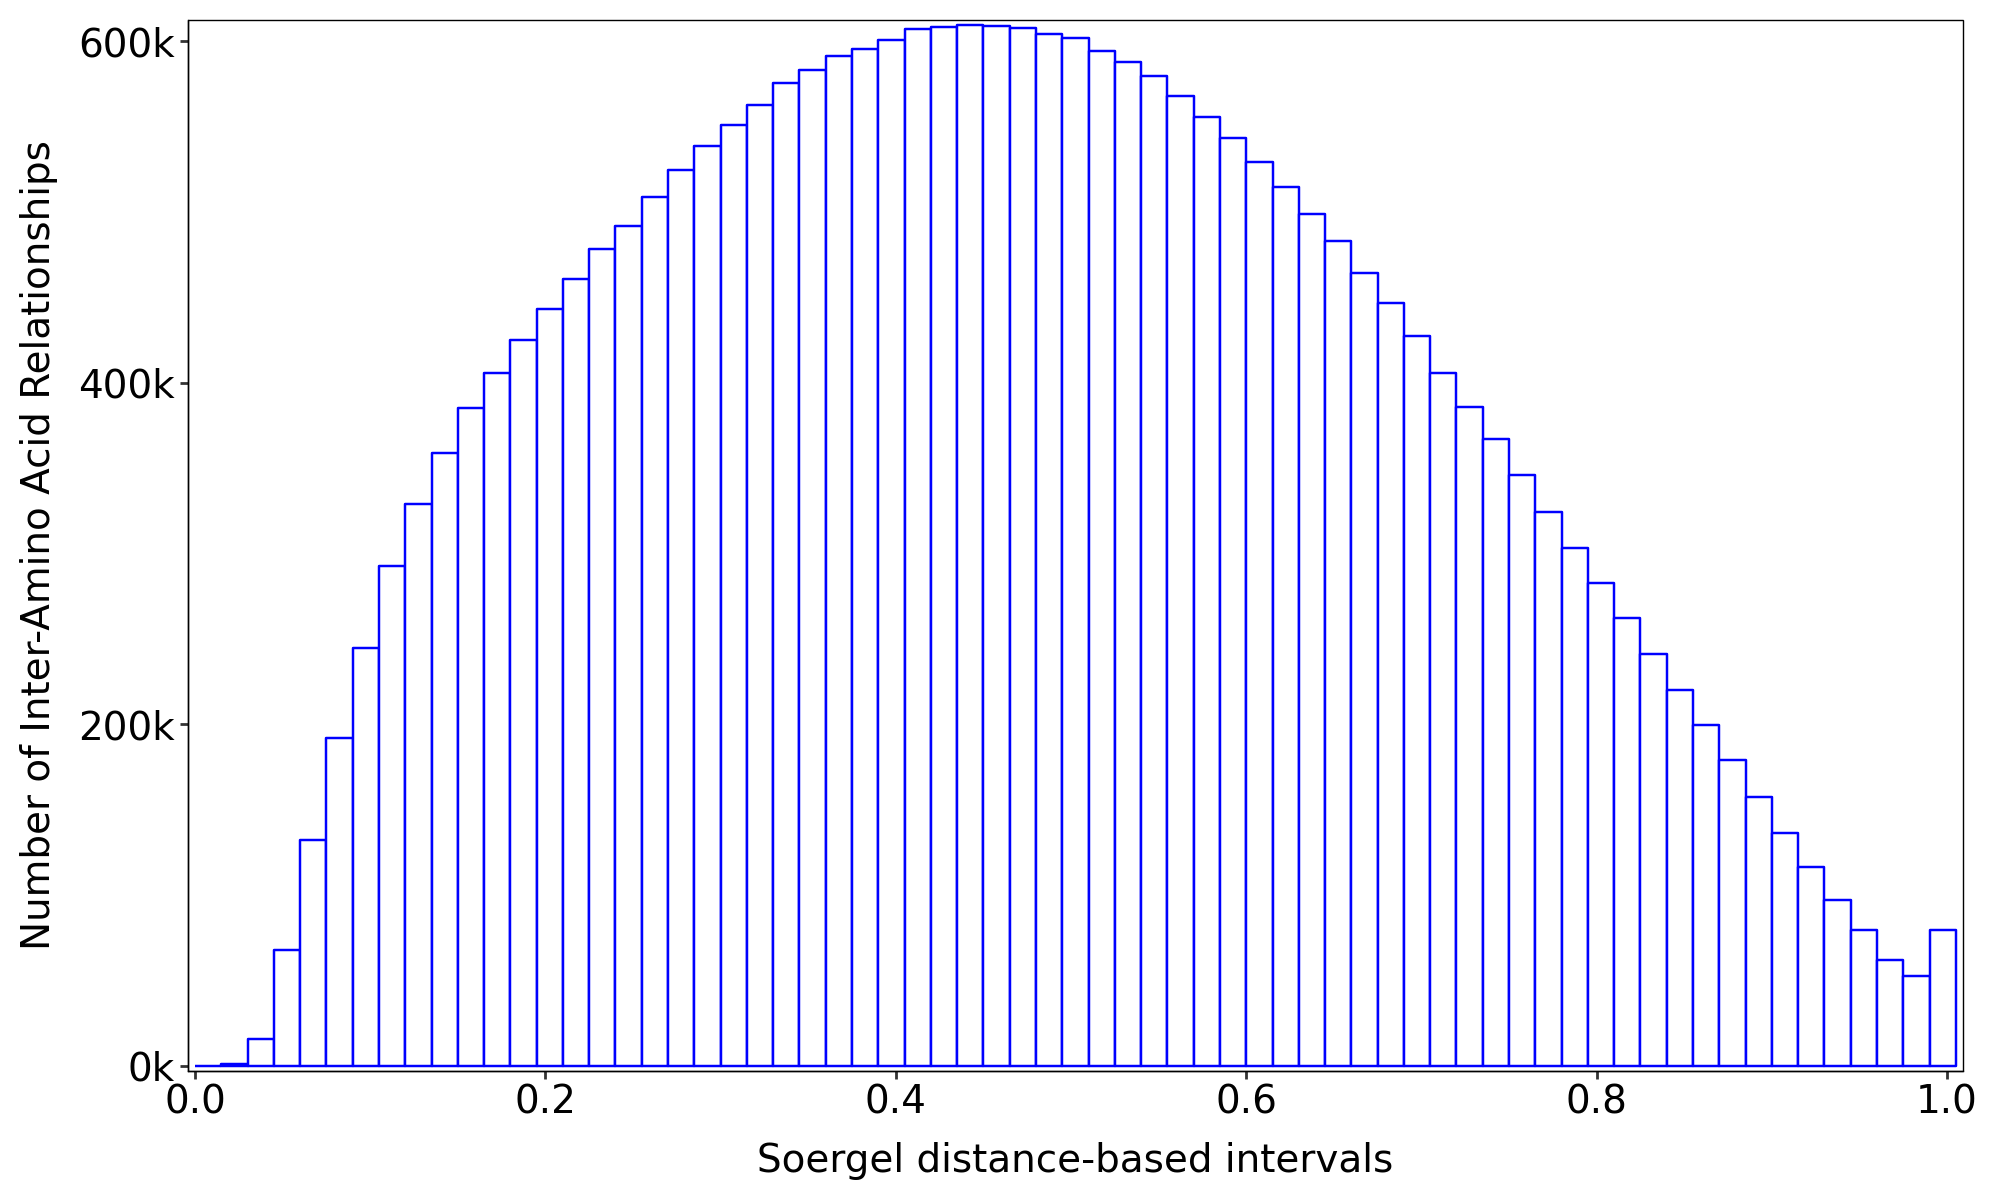

In [8]:
distance_function = 'soergel'
x_axis_step = 0.2
binwidth = 0.015

distances_filepath = f'{base_path}Inter_Amino_Acid_Distances-{distance_function}.csv'
output_filepath = f'{output_base_path}Inter_Amino_Acid_Distances-{distance_function}.png'
plot_inter_amino_acid_distances(distances_filepath, distance_function, x_axis_step, binwidth, output_filepath)

## **Edges analysis**

### **Graph density** 

In [ ]:
input_filepath = f'{base_path}Graph-information.csv'
output_filepath = f'{output_base_path}Density_per_Distance_Function.png'
plot, graph_info = plot_density(input_filepath, output_filepath)
plot.show()

### **Empty graph**

In [ ]:
zero_edges = graph_info[graph_info['number_of_edges'] == 0]
count_zero_edges = zero_edges.groupby(['distance_function', 'interval'], observed=True).size()
count_zero_edges.head(10)

### **Edge statistics**

In [ ]:
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75]
edge_stats_by_function = graph_info.groupby('distance_function', observed=True)['number_of_edges'].describe(percentiles=percentiles)
edge_stats_by_function.head(7)

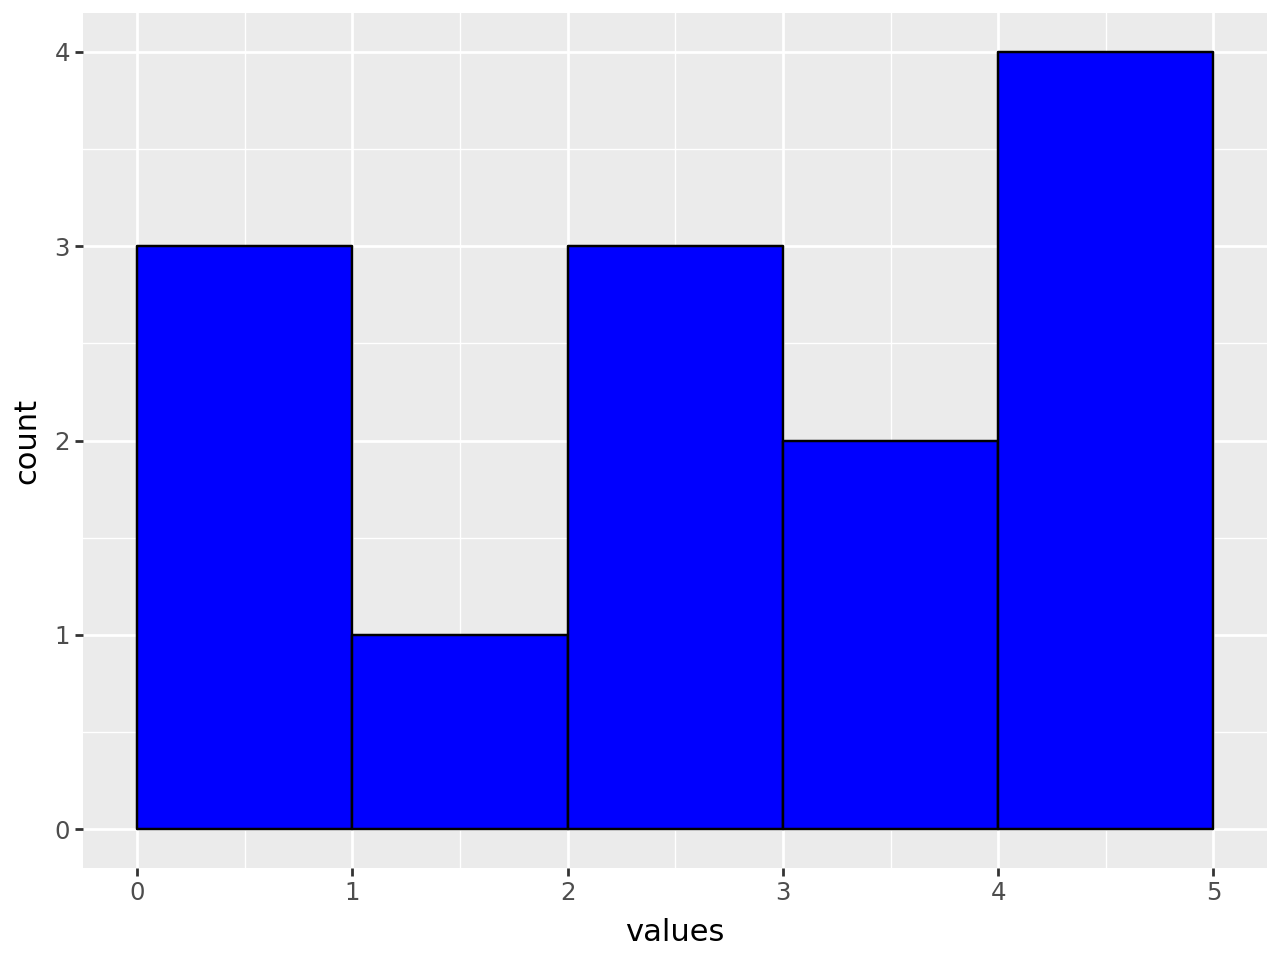

In [27]:
from plotnine import ggplot, aes, geom_histogram, scale_x_continuous
import pandas as pd

# Datos de ejemplo
data = pd.DataFrame({
    'values': [0, 0, 1, 2, 3, 3, 3, 4, 4, 5, 5, 5, 5]
})

# Crear un histograma con el eje x comenzando en cero
plot = (
    ggplot(data, aes(x='values')) +
    geom_histogram(binwidth=1, fill="blue", color="black", boundary=0) +  # Configura el binwidth según tus necesidades
    scale_x_continuous(limits=(0, None))  # Asegura que el eje x comience en cero
)

plot.show()